In [1]:
import sys
print(sys.executable)
print(sys.path)

/usr/bin/python3
['/content', '/env/python', '/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload', '', '/usr/local/lib/python3.12/dist-packages', '/usr/lib/python3/dist-packages', '/usr/local/lib/python3.12/dist-packages/IPython/extensions', '/root/.ipython']


In [2]:
%%time
!pip -q install lightning
# Wall time: 1min 9s  2408
# Wall time: 5.32 s   2411
# Wall time: 1min 32s 2505
# Wall time: 11.1 s   2510

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 828.5/828.5 kB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 60.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 832.4/832.4 kB 63.7 MB/s eta 0:00:00
CPU times: user 13.3 ms, sys: 101 µs, total: 13.4 ms
Wall time: 5.82 s


In [3]:
import torch
import lightning as L
import numpy as np
import pandas as pd
import matplotlib as mpl

In [4]:
!python --version
torch.__version__,L.__version__,np.__version__,pd.__version__,mpl.__version__
#Python 3.10.12   2411
#Python 3.11.12   2505
#Python 3.12.12   2510

#('2.0.1+cu118', '2.0.8', '1.23.5', '1.5.3', '3.7.1')       2404
#('2.3.0+cu121', '2.3.0', '1.25.2', '2.0.3', '3.7.1')       2406
#('2.3.1+cu121', '2.4.0', '1.26.4', '2.1.4', '3.7.1')       2408
#('2.5.1+cu121', '2.4.0', '1.26.4', '2.2.2', '3.8.0')       2411
#('2.6.0+cu124', '2.5.1.post0', '2.0.2', '2.2.2', '3.10.0') 2505
#('2.8.0+cu126', '2.5.5', '2.0.2', '2.2.2', '3.10.0')       2510

Python 3.12.12


('2.8.0+cu126', '2.5.5', '2.0.2', '2.2.2', '3.10.0')

In [5]:
import platform
platform.platform()
# Linux-6.1.85+-x86_64-with-glibc2.35   2505

'Linux-6.6.105+-x86_64-with-glibc2.35'

In [6]:
import tensorflow as tf
from tensorflow.python.client import device_lib

print(tf.config.list_physical_devices())
print("============")
print(device_lib.list_local_devices())

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 6162033559085714812
xla_global_id: -1
, name: "/device:GPU:0"
device_type: "GPU"
memory_limit: 14619377664
locality {
  bus_id: 1
  links {
  }
}
incarnation: 8120527288171087939
physical_device_desc: "device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5"
xla_global_id: 416903419
]


In [7]:
import os
os.cpu_count() #T4:2 or 8, L4:6 or 12, V100:8 or

2

In [8]:
!nvidia-smi -L

GPU 0: Tesla T4 (UUID: GPU-aded75c0-8e85-257f-8aef-7da49e7bdb80)


In [9]:
!lscpu  # @T4: CPUs: 2, 고용량RAM 환경: CPUs: 8
        # @L4: CPUs: 12(6)

Architecture:                x86_64
  CPU op-mode(s):            32-bit, 64-bit
  Address sizes:             46 bits physical, 48 bits virtual
  Byte Order:                Little Endian
CPU(s):                      2
  On-line CPU(s) list:       0,1
Vendor ID:                   GenuineIntel
  Model name:                Intel(R) Xeon(R) CPU @ 2.20GHz
    CPU family:              6
    Model:                   79
    Thread(s) per core:      2
    Core(s) per socket:      1
    Socket(s):               1
    Stepping:                0
    BogoMIPS:                4399.99
    Flags:                   fpu vme de pse tsc msr pae mce cx8 apic sep mtrr pg
                             e mca cmov pat pse36 clflush mmx fxsr sse sse2 ss h
                             t syscall nx pdpe1gb rdtscp lm constant_tsc rep_goo
                             d nopl xtopology nonstop_tsc cpuid tsc_known_freq p
                             ni pclmulqdq ssse3 fma cx16 pcid sse4_1 sse4_2 x2ap
                   

In [10]:
# GPU 또는 CPU 디바이스 설정
device = (
    "cuda"
    if torch.cuda.is_available()  # CUDA가 가능하면 GPU 사용
    else "mps"                    # MacOS Metal 지원 시 GPU 사용
    if torch.backends.mps.is_available()
    else "cpu")

device

'cuda'

In [11]:
import psutil

# CPU 메모리 사용량
process = psutil.Process(os.getpid())
print(f"전체 CPU 메모리: {psutil.virtual_memory().total / (1024**3):.2f} GB")
print(f"사용 중인 CPU 메모리: {psutil.virtual_memory().used / (1024**3):.2f} GB")
print(f"사용 가능한 CPU 메모리: {psutil.virtual_memory().available / (1024**3):.2f} GB")

전체 CPU 메모리: 12.67 GB
사용 중인 CPU 메모리: 1.71 GB
사용 가능한 CPU 메모리: 10.66 GB


In [12]:
# GPU 메모리 사용량

device = torch.cuda.current_device()
print(f"GPU: {torch.cuda.get_device_name(device)}")
print(f"전체 GPU 메모리: {torch.cuda.get_device_properties(device).total_memory / (1024**3):.2f} GB")
print(f"현재 할당된 GPU 메모리: {torch.cuda.memory_allocated(device) / (1024**3):.2f} GB")
print(f"현재 캐시된 GPU 메모리: {torch.cuda.memory_reserved(device) / (1024**3):.2f} GB")

GPU: Tesla T4
전체 GPU 메모리: 14.74 GB
현재 할당된 GPU 메모리: 0.00 GB
현재 캐시된 GPU 메모리: 0.00 GB


In [13]:
# Disk 사용량

disk = psutil.disk_usage('/')
total_disk = disk.total / (1024**3)
used_disk = disk.used / (1024**3)
free_disk = disk.free / (1024**3)
print(f"\n=== Disk ===")
print(f"전체: {total_disk:.2f} GB, 사용: {used_disk:.2f} GB, 사용 가능: {free_disk:.2f} GB")


=== Disk ===
전체: 235.68 GB, 사용: 39.72 GB, 사용 가능: 195.94 GB


G-drive mount 하기


In [ ]:
# (Google Drive 연결 셀 제거 — 저장 경로는 /content/models/PT/ 로 바꿨다)


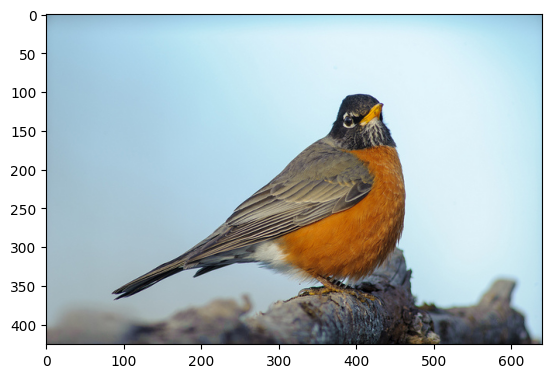

In [15]:
import matplotlib.pyplot as plt

# set test file path
bird_file_path = '/content/datasets/'
bird_file_path = bird_file_path +'bird.jpg'
img = plt.imread(bird_file_path)
# check image
plt.imshow(img)

---
**사내에서 python package install 주의사항**

```python
## Proxy 서버 IP 설정/ 방화벽으로 차단된 경우 ##
pip install matplotlib #기본 형식

## 사내에서 install하기 위해서는
# proxy 서버를 통해야 함, 따라서 아래 형식을 따라야 설치 가능함
# proxy 서버의 IP주소를 넣어 주어야 됨

pip install --upgrade --user --proxy https://12.26.226.2:8080 --trusted-host pypi.python.org --trusted-host pypi.org --trusted-host files.pythonhosted.org matplotlib

# 부서에 따라 proxy 서버의 IP주소가 다르므로, 보안부서에 문의 필요
## DSR : https://12.26.226.2:8080
## 종합기술원  : http://75.12.251.5:8080
```

**PyTorch Ref. site**
* PyTorch   
https://pytorch.org/docs/stable/index.html  : PyTorch Doc  
https://pytorch.kr/ : PyTorch Korea  
* Lightning   
https://lightning.ai/ : Lightning AI   
* PyTorch Lightning  
https://pytorch-lightning.readthedocs.io/en/stable/index.html : PyTorch  Lightning Doc  
https://pytorch-lightning.readthedocs.io/en/stable/common/lightning_module.html : LightningModule Doc  
https://pytorch-lightning.readthedocs.io/en/stable/common/trainer.html : Trainer Doc  
https://pytorch-lightning.readthedocs.io/en/stable/api_references.html : API Reference  
https://pytorch-lightning.readthedocs.io/en/stable/starter/core_guide.html : Tutorials  
